In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [30]:
data=pd.read_csv("dataset/car_purchasing.csv", encoding="latin-1")

In [31]:
data.head()

,customer name,customer e-mail,country,gender,age,annual Salary,credit card debt,net worth,car purchase amount
0,Martina Avila,cubilia.Curae.Phasellus@quisaccumsanconvallis.edu,Bulgaria,0,41.851720,62812.09301,11609.380910,238961.2505,35321.45877
1,Harlan Barnes,eu.dolor@diam.co.uk,Belize,0,40.870623,66646.89292,9572.957136,530973.9078,45115.52566
2,Naomi Rodriquez,vulputate.mauris.sagittis@ametconsectetueradip...,Algeria,1,43.152897,53798.55112,11160.355060,638467.1773,42925.70921
3,Jade Cunningham,malesuada@dignissim.com,Cook Islands,1,58.271369,79370.03798,14426.164850,548599.0524,67422.36313
4,Cedric Leach,felis.ullamcorper.viverra@egetmollislectus.net,Brazil,1,57.313749,59729.15130,5358.712177,560304.0671,55915.46248


In [32]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   customer name        500 non-null    object 
 1   customer e-mail      500 non-null    object 
 2   country              500 non-null    object 
 3   gender               500 non-null    int64  
 4   age                  500 non-null    float64
 5   annual Salary        500 non-null    float64
 6   credit card debt     500 non-null    float64
 7   net worth            500 non-null    float64
 8   car purchase amount  500 non-null    float64
dtypes: float64(5), int64(1), object(3)
memory usage: 35.3+ KB


In [33]:
data.isna().sum()

customer name          0
customer e-mail        0
country                0
gender                 0
age                    0
annual Salary          0
credit card debt       0
net worth              0
car purchase amount    0
dtype: int64

In [34]:
data.shape

(500, 9)

In [35]:
data.columns

Index(['customer name', 'customer e-mail', 'country', 'gender', 'age',
       'annual Salary', 'credit card debt', 'net worth',
       'car purchase amount'],
      dtype='object')

In [36]:
numeric_columns=data[['age',
       'annual Salary', 'credit card debt', 'net worth',
       'car purchase amount']]



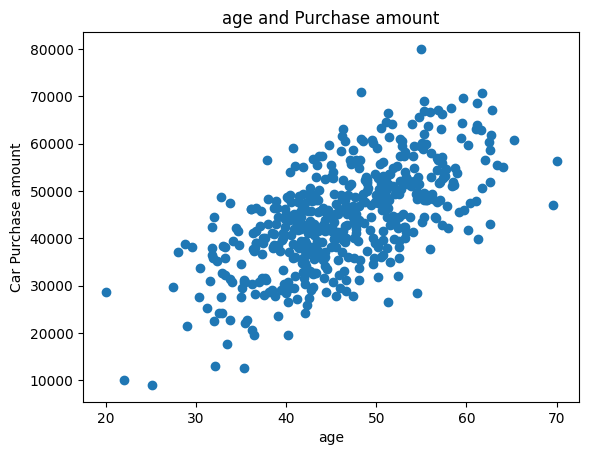

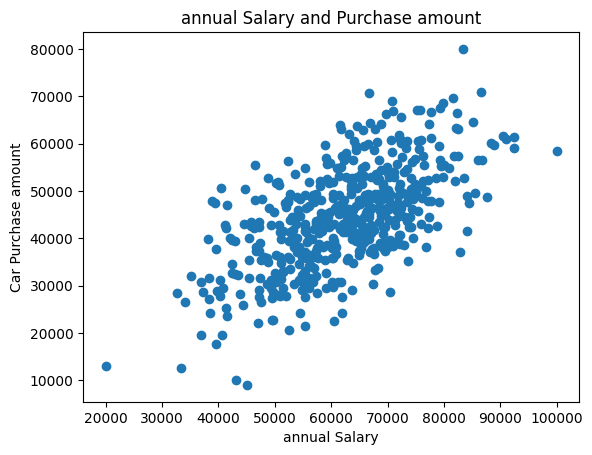

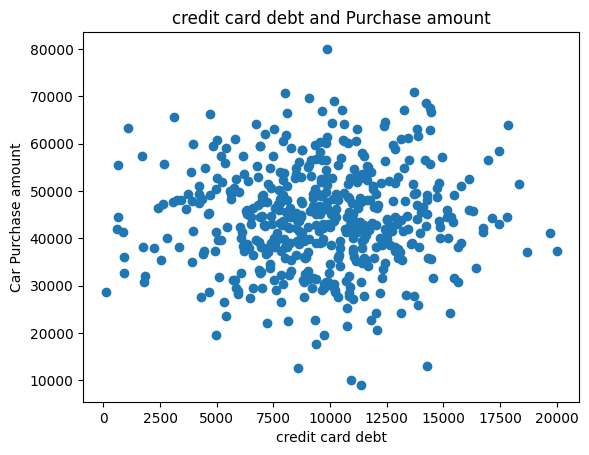

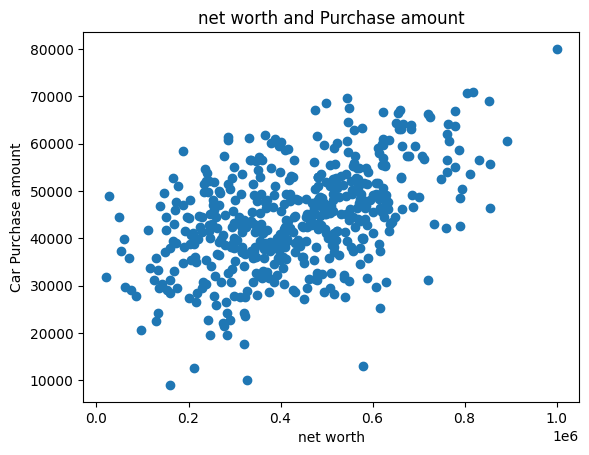

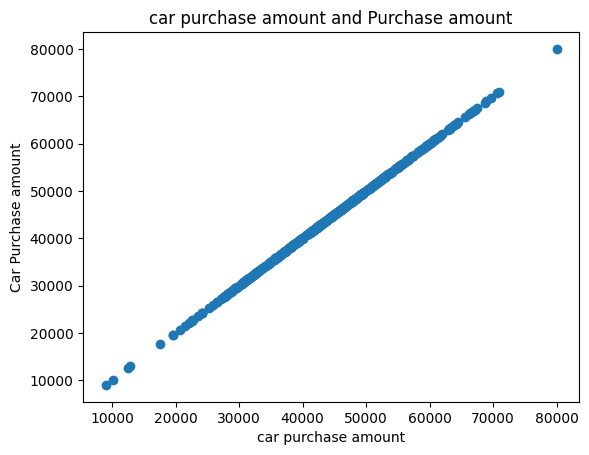

In [37]:
for i in numeric_columns.columns:
    plt.scatter(data[i],data["car purchase amount"])
    plt.title(f"{i} and Purchase amount")
    plt.xlabel(i)
    plt.ylabel("Car Purchase amount")
    plt.show()


In [38]:
data["gender_label"]=data["gender"].apply(lambda x:"Female" if x==1 else "Male" )

In [39]:
data

,customer name,customer e-mail,country,gender,age,annual Salary,credit card debt,net worth,car purchase amount,gender_label
0,Martina Avila,cubilia.Curae.Phasellus@quisaccumsanconvallis.edu,Bulgaria,0,41.851720,62812.09301,11609.380910,238961.2505,35321.45877,Male
1,Harlan Barnes,eu.dolor@diam.co.uk,Belize,0,40.870623,66646.89292,9572.957136,530973.9078,45115.52566,Male
2,Naomi Rodriquez,vulputate.mauris.sagittis@ametconsectetueradip...,Algeria,1,43.152897,53798.55112,11160.355060,638467.1773,42925.70921,Female
3,Jade Cunningham,malesuada@dignissim.com,Cook Islands,1,58.271369,79370.03798,14426.164850,548599.0524,67422.36313,Female
4,Cedric Leach,felis.ullamcorper.viverra@egetmollislectus.net,Brazil,1,57.313749,59729.15130,5358.712177,560304.0671,55915.46248,Female
...,...,...,...,...,...,...,...,...,...,...
495,Walter,ligula@Cumsociis.ca,Nepal,0,41.462515,71942.40291,6995.902524,541670.1016,48901.44342,Male
496,Vanna,Cum.sociis.natoque@Sedmolestie.edu,Zimbabwe,1,37.642000,56039.49793,12301.456790,360419.0988,31491.41457,Female
497,Pearl,penatibus.et@massanonante.com,Philippines,1,53.943497,68888.77805,10611.606860,764531.3203,64147.28888,Female
498,Nell,Quisque.varius@arcuVivamussit.net,Botswana,1,59.160509,49811.99062,14013.034510,337826.6382,45442.15353,Female


In [40]:
data["gender_label"].value_counts()

gender_label
Female    253
Male      247
Name: count, dtype: int64

<Axes: xlabel='gender_label'>

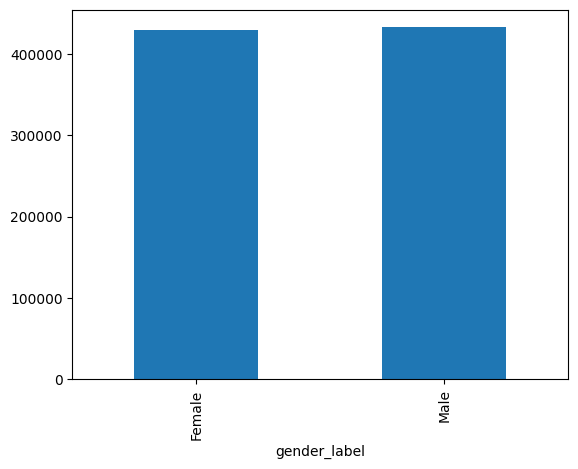

In [41]:
data.groupby("gender_label")["net worth"].mean().plot(kind="bar")

In [42]:
def age_groups_creation(row):
    if row["age"] < 30:
        return "20 - 30"
    elif row["age"]<40:
        return "30-40"
    elif row["age"]<50: 
        return "40-50"
    elif row["age"]<60: 
        return "50-60"
    else:
        return "60-70"
        

In [43]:
data['age'].min()

np.float64(20.0)

In [44]:
data['age_range']=data.apply(age_groups_creation,axis=1)

In [45]:
data

,customer name,customer e-mail,country,gender,age,annual Salary,credit card debt,net worth,car purchase amount,gender_label,age_range
0,Martina Avila,cubilia.Curae.Phasellus@quisaccumsanconvallis.edu,Bulgaria,0,41.851720,62812.09301,11609.380910,238961.2505,35321.45877,Male,40-50
1,Harlan Barnes,eu.dolor@diam.co.uk,Belize,0,40.870623,66646.89292,9572.957136,530973.9078,45115.52566,Male,40-50
2,Naomi Rodriquez,vulputate.mauris.sagittis@ametconsectetueradip...,Algeria,1,43.152897,53798.55112,11160.355060,638467.1773,42925.70921,Female,40-50
3,Jade Cunningham,malesuada@dignissim.com,Cook Islands,1,58.271369,79370.03798,14426.164850,548599.0524,67422.36313,Female,50-60
4,Cedric Leach,felis.ullamcorper.viverra@egetmollislectus.net,Brazil,1,57.313749,59729.15130,5358.712177,560304.0671,55915.46248,Female,50-60
...,...,...,...,...,...,...,...,...,...,...,...
495,Walter,ligula@Cumsociis.ca,Nepal,0,41.462515,71942.40291,6995.902524,541670.1016,48901.44342,Male,40-50
496,Vanna,Cum.sociis.natoque@Sedmolestie.edu,Zimbabwe,1,37.642000,56039.49793,12301.456790,360419.0988,31491.41457,Female,30-40
497,Pearl,penatibus.et@massanonante.com,Philippines,1,53.943497,68888.77805,10611.606860,764531.3203,64147.28888,Female,50-60
498,Nell,Quisque.varius@arcuVivamussit.net,Botswana,1,59.160509,49811.99062,14013.034510,337826.6382,45442.15353,Female,50-60


In [46]:
data["age_range"].value_counts()

age_range
40-50      231
50-60      142
30-40       96
60-70       23
20 - 30      8
Name: count, dtype: int64

Text(0, 0.5, 'Frequency')

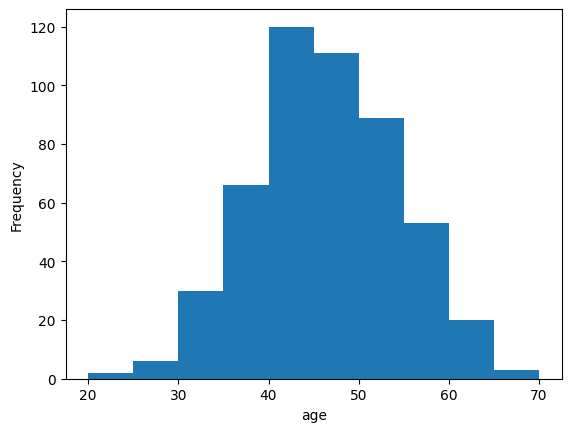

In [47]:
plt.hist(data["age"])
plt.xlabel("age")
plt.ylabel("Frequency")

In [48]:
data.columns

Index(['customer name', 'customer e-mail', 'country', 'gender', 'age',
       'annual Salary', 'credit card debt', 'net worth', 'car purchase amount',
       'gender_label', 'age_range'],
      dtype='object')

<Axes: xlabel='age_range'>

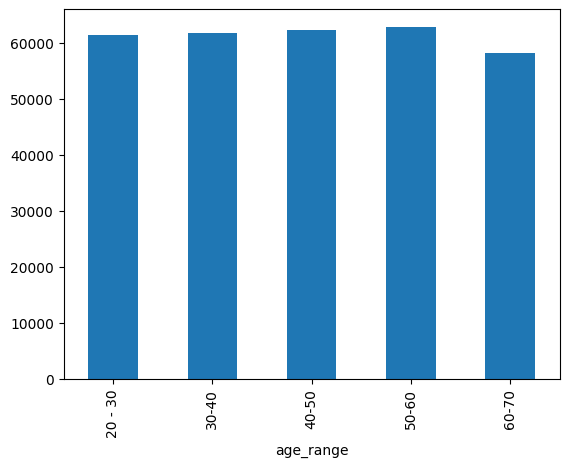

In [49]:
data.groupby("age_range")["annual Salary"].mean().plot(kind="bar")

In [50]:
data.groupby("age_range")["car purchase amount"].mean()

age_range
20 - 30    26615.206629
30-40      35268.386125
40-50      43137.498874
50-60      51064.837759
60-70      56097.551587
Name: car purchase amount, dtype: float64

In [51]:
data.columns

Index(['customer name', 'customer e-mail', 'country', 'gender', 'age',
       'annual Salary', 'credit card debt', 'net worth', 'car purchase amount',
       'gender_label', 'age_range'],
      dtype='object')

In [52]:
data.groupby(["age_range","gender_label"])["annual Salary"].mean().reset_index()

,age_range,gender_label,annual Salary
0,20 - 30,Female,61656.174270
1,20 - 30,Male,61101.667473
2,30-40,Female,60474.781313
3,30-40,Male,63300.221926
4,40-50,Female,61293.340418
5,40-50,Male,63347.080071
6,50-60,Female,63165.221037
7,50-60,Male,62529.281355
8,60-70,Female,63876.773028
9,60-70,Male,53885.836882


In [53]:
data.columns

Index(['customer name', 'customer e-mail', 'country', 'gender', 'age',
       'annual Salary', 'credit card debt', 'net worth', 'car purchase amount',
       'gender_label', 'age_range'],
      dtype='object')

In [54]:
X=data[["age","annual Salary","net worth"]]
y=data["car purchase amount"]

In [55]:
X

,age,annual Salary,net worth
0,41.851720,62812.09301,238961.2505
1,40.870623,66646.89292,530973.9078
2,43.152897,53798.55112,638467.1773
3,58.271369,79370.03798,548599.0524
4,57.313749,59729.15130,560304.0671
...,...,...,...
495,41.462515,71942.40291,541670.1016
496,37.642000,56039.49793,360419.0988
497,53.943497,68888.77805,764531.3203
498,59.160509,49811.99062,337826.6382


In [56]:
import sklearn
print(sklearn.__version__)

1.8.0


In [57]:
from sklearn.model_selection import train_test_split
X_train,X_test, y_train,y_test= train_test_split(X,y,test_size=0.2)

In [58]:
from sklearn.preprocessing import StandardScaler

In [59]:
scaler=StandardScaler()

In [60]:
X_train= scaler.fit_transform(X_train)

In [61]:
import joblib
joblib.dump(scaler,"scaler.pkl")

['scaler.pkl']

In [62]:
X_test= scaler.fit_transform(X_test)

In [63]:
X

,age,annual Salary,net worth
0,41.851720,62812.09301,238961.2505
1,40.870623,66646.89292,530973.9078
2,43.152897,53798.55112,638467.1773
3,58.271369,79370.03798,548599.0524
4,57.313749,59729.15130,560304.0671
...,...,...,...
495,41.462515,71942.40291,541670.1016
496,37.642000,56039.49793,360419.0988
497,53.943497,68888.77805,764531.3203
498,59.160509,49811.99062,337826.6382


In [64]:
X_train

array([[ 0.55680922, -0.15653769,  0.48416028],
       [-0.52871836, -2.06856261,  0.91172377],
       [ 0.50199963,  1.03386183, -0.82346112],
       ...,
       [-0.14925117, -0.1417792 , -0.81906095],
       [ 0.55123083,  0.83896664, -1.53119441],
       [ 0.09177681,  0.60005404,  0.44325319]], shape=(400, 3))

In [65]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [66]:
def modelresults(predictions):
    print("RMSE: {}".format(np.sqrt(mean_squared_error(y_test, predictions))))
    print("MAE: {}".format(mean_absolute_error(y_test, predictions)))

In [67]:
from sklearn.linear_model import LinearRegression
lr=LinearRegression()


In [68]:
lr.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [69]:
predictions_linear_regression=lr.predict(X_test)

In [70]:
modelresults(predictions_linear_regression)

RMSE: 657.9737162164984
MAE: 533.5873092207353


In [71]:
data["car purchase amount"].describe()

count      500.000000
mean     44209.799218
std      10773.178744
min       9000.000000
25%      37629.896040
50%      43997.783390
75%      51254.709517
max      80000.000000
Name: car purchase amount, dtype: float64

In [72]:
lr.coef_

array([6798.19476194, 6505.62530453, 4950.89539284])

In [73]:
from sklearn.svm import SVR


In [74]:
svrmodel=SVR()
svrmodel.fit(X_train,y_train)

,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm.If none is given, 'rbf' will be used. If a callable is given it isused to precompute the kernel matrix.For an intuitive visualization of different kernel typessee :ref:`sphx_glr_auto_examples_svm_plot_svm_regression.py`",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive.The penalty is a squared l2. For an intuitive visualization of theeffects of scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"epsilon epsilon: float, default=0.1Epsilon in the epsilon-SVR model. It specifies the epsilon-tubewithin which no penalty is associated in the training loss functionwith points predicted within a distance epsilon from the actualvalue. Must be non-negative.",0.1
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False
,"max_iter max_iter: int, default=-1Hard limit on iterations within solver, or -1 for no limit.",-1


In [75]:
predictions_svm=svrmodel.predict(X_test)

In [76]:
modelresults(predictions_svm)

RMSE: 11273.090780353905
MAE: 8659.560525215005


In [77]:
joblib.dump(lr,"model.pkl")

['model.pkl']